# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [19]:
# Import library dasar
import numpy as np
import pandas as pd

# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Import library untuk data splitting
from sklearn.model_selection import train_test_split

# Import library untuk model klasifikasi
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Import library untuk evaluasi
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Import library untuk tuning
from sklearn.model_selection import GridSearchCV

# Pengaturan visualisasi
%matplotlib inline
sns.set_style("whitegrid")

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [20]:
# Memuat dataset
df = pd.read_csv("data/bank_transaction_segmented_dataset.csv")

# Menampilkan 5 baris pertama
print("5 Baris Pertama Dataset:")
print(df.head())

# Memeriksa informasi dataset
print("\nInformasi Dataset:")
print(df.info())

5 Baris Pertama Dataset:
   TransactionID  AccountID  TransactionAmount  Location  DeviceID  \
0      -1.731361  -0.841708          -1.510833        36  0.137594   
1      -1.729982   1.418890           0.672289        15 -1.451941   
2      -1.728603  -1.595241          -0.538647        23 -0.548682   
3      -1.727224  -1.246384          -0.152595        33 -0.785850   
4      -1.725845   1.111896          -1.517277         1 -0.200498   

   MerchantID  Channel  CustomerAge  CustomerOccupation  TransactionDuration  \
0   -1.189384        0     1.423718                   0            -0.475448   
1    0.085305        0     1.311287                   0             0.446104   
2   -1.396090        2    -1.443277                   3            -0.940661   
3   -1.637248        2    -1.049768                   3            -1.577340   
4    1.428896        2    -1.049768                   3             1.122718   

   ...       IP1       IP2       IP3       IP4  TransactionType_Debit  \


# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [21]:
features = ['TransactionAmount', 'CustomerAge', 'AccountBalance', 'TransactionDuration', 
            'LoginAttempts', 'TransactionType_Debit', 'IP1', 'IP2', 'IP3', 'IP4']
X = df[features]
y = df['Cluster_After_FS']  # Target adalah Cluster_After_FS

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [22]:
# Model Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Model KNN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

Tulis narasi atau penjelasan algoritma yang Anda gunakan.

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

In [23]:
# Prediksi
rf_pred = rf_model.predict(X_test)
knn_pred = knn_model.predict(X_test)

# Evaluasi Random Forest
print("Evaluasi Random Forest:")
print(f"Akurasi: {accuracy_score(y_test, rf_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_pred, average='weighted'):.4f}")

# Evaluasi KNN
print("\nEvaluasi KNN:")
print(f"Akurasi: {accuracy_score(y_test, knn_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, knn_pred, average='weighted'):.4f}")

Evaluasi Random Forest:
Akurasi: 0.9980
F1-Score: 0.9970

Evaluasi KNN:
Akurasi: 0.9980
F1-Score: 0.9970


Tulis hasil evaluasi algoritma yang digunakan, jika Anda menggunakan 2 algoritma, maka bandingkan hasilnya.

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [24]:
# Tuning Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, scoring='f1_weighted')
rf_grid.fit(X_train, y_train)

# Tuning KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='f1_weighted')
knn_grid.fit(X_train, y_train)

# Model terbaik
best_rf = rf_grid.best_estimator_
best_knn = knn_grid.best_estimator_

c:\Project Alif\Dicoding Machine Learning\Fraud-Detection-Project-With-Machine-Learning\myvenv\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Project Alif\Dicoding Machine Learning\Fraud-Detection-Project-With-Machine-Learning\myvenv\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

In [25]:
# Prediksi dengan model terbaik
best_rf_pred = best_rf.predict(X_test)
best_knn_pred = best_knn.predict(X_test)

# Evaluasi Random Forest setelah tuning
print("Evaluasi Random Forest setelah Tuning:")
print(f"Akurasi: {accuracy_score(y_test, best_rf_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, best_rf_pred, average='weighted'):.4f}")

# Evaluasi KNN setelah tuning
print("\nEvaluasi KNN setelah Tuning:")
print(f"Akurasi: {accuracy_score(y_test, best_knn_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, best_knn_pred, average='weighted'):.4f}")

Evaluasi Random Forest setelah Tuning:
Akurasi: 0.9980
F1-Score: 0.9970

Evaluasi KNN setelah Tuning:
Akurasi: 0.9980
F1-Score: 0.9970


# PREDIKSI REKOMENDASI LIMIT KREDIT

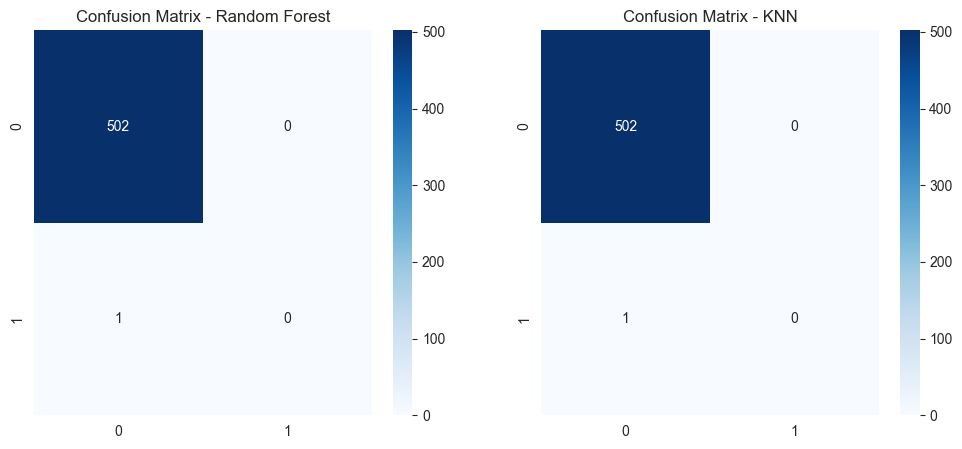

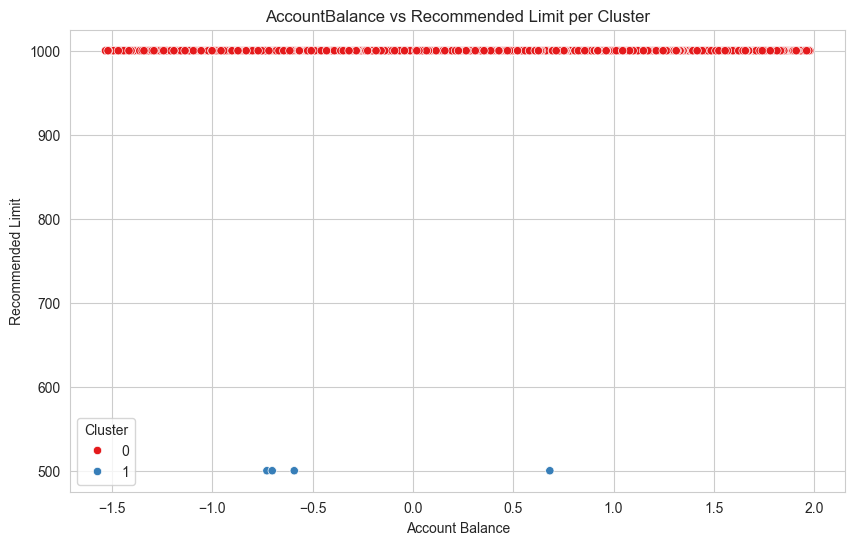

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12964\3356379959.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Predicted_Cluster', y='Recommended_Limit', data=df, palette='Set2')


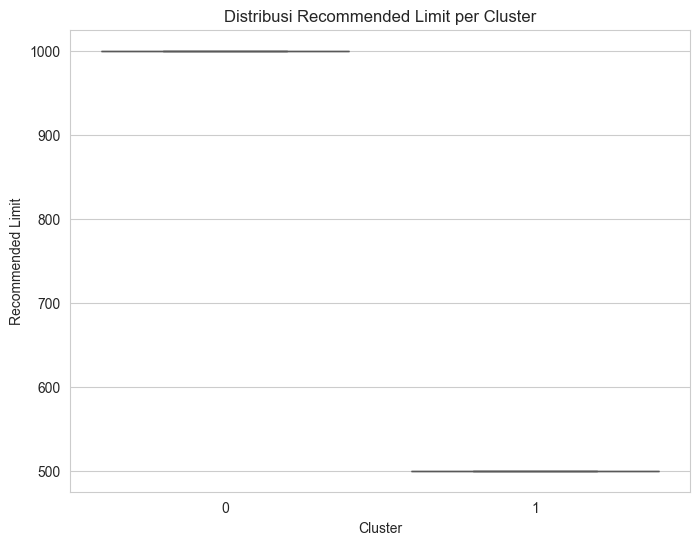

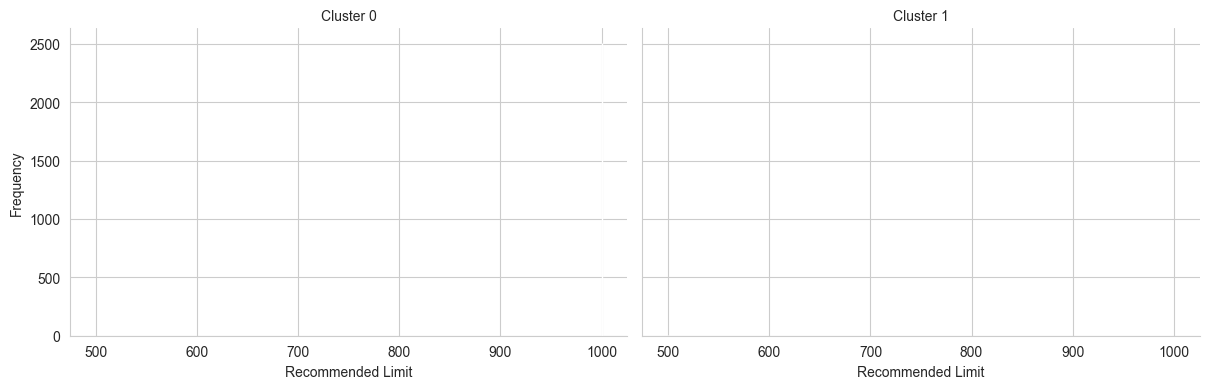

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12964\3356379959.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Predicted_Cluster', y='Recommended_Limit', data=cluster_avg_limit, palette='Set3')


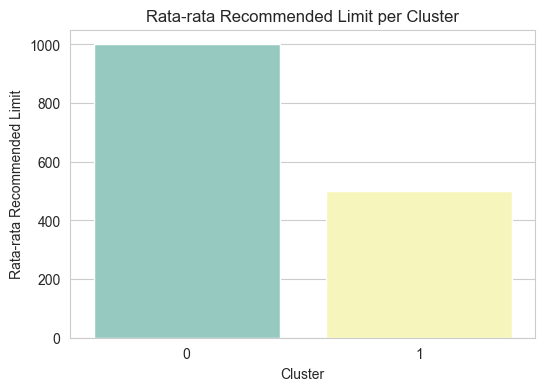

Dataset dengan rekomendasi limit disimpan ke 'data/bank_transaction_with_recommendations.csv'


In [26]:
# Visualisasi Confusion Matrix
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, best_rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, best_knn_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - KNN')
plt.show()

# Rekomendasi Limit Kartu Kredit
# Tambahkan prediksi cluster ke dataframe
df['Predicted_Cluster'] = best_rf.predict(X_scaled)

# Fungsi untuk menetapkan limit
def assign_credit_limit(row):
    if row['Predicted_Cluster'] == 0:
        base_limit = row['AccountBalance'] * 0.5
        return min(max(base_limit, 1000), 10000)  # Limit antara 1000 - 10000
    elif row['Predicted_Cluster'] == 1:
        base_limit = row['AccountBalance'] * 0.3
        return min(max(base_limit, 500), 5000)    # Limit antara 500 - 5000
    else:
        return 1000  # Default limit untuk cluster lain

df['Recommended_Limit'] = df.apply(assign_credit_limit, axis=1)

# Visualisasi Rekomendasi
# Scatter Plot: AccountBalance vs Recommended_Limit per Cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(x='AccountBalance', y='Recommended_Limit', hue='Predicted_Cluster', data=df, palette='Set1')
plt.title('AccountBalance vs Recommended Limit per Cluster')
plt.xlabel('Account Balance')
plt.ylabel('Recommended Limit')
plt.legend(title='Cluster')
plt.show()

# Box Plot: Distribusi Recommended_Limit per Cluster
plt.figure(figsize=(8, 6))
sns.boxplot(x='Predicted_Cluster', y='Recommended_Limit', data=df, palette='Set2')
plt.title('Distribusi Recommended Limit per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Recommended Limit')
plt.show()

# Histogram: Distribusi Recommended_Limit per Cluster
g = sns.FacetGrid(df, col='Predicted_Cluster', height=4, aspect=1.5)
g.map(plt.hist, 'Recommended_Limit', bins=20, color='skyblue')
g.set_axis_labels('Recommended Limit', 'Frequency')
g.set_titles('Cluster {col_name}')
plt.show()

# Bar Plot: Rata-rata Recommended_Limit per Cluster
cluster_avg_limit = df.groupby('Predicted_Cluster')['Recommended_Limit'].mean().reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(x='Predicted_Cluster', y='Recommended_Limit', data=cluster_avg_limit, palette='Set3')
plt.title('Rata-rata Recommended Limit per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Rata-rata Recommended Limit')
plt.show()

# Simpan Hasil
df.to_csv("data/bank_transaction_with_recommendations.csv", index=False)
print("Dataset dengan rekomendasi limit disimpan ke 'data/bank_transaction_with_recommendations.csv'")

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Bandingkan hasil evaluasi sebelum dan setelah tuning (jika dilakukan).
2. Identifikasi kelemahan model, seperti:
  - Precision atau Recall rendah untuk kelas tertentu.
  - Apakah model mengalami overfitting atau underfitting?
3. Berikan rekomendasi tindakan lanjutan, seperti mengumpulkan data tambahan atau mencoba algoritma lain jika hasil belum memuaskan.


Perbandingan Performa Model:
----------------------------------------
Random Forest (Sebelum Tuning):
  Akurasi: 0.9980
  F1-Score: 0.9970
----------------------------------------
Random Forest (Setelah Tuning):
  Akurasi: 0.9980
  F1-Score: 0.9970
----------------------------------------
KNN (Sebelum Tuning):
  Akurasi: 0.9980
  F1-Score: 0.9970
----------------------------------------
KNN (Setelah Tuning):
  Akurasi: 0.9980
  F1-Score: 0.9970
----------------------------------------

Analisis Kelemahan Model:
----------------------------------------
Random Forest:
  - Confusion Matrix:
 [[502   0]
 [  1   0]]
  - Precision dan Recall per kelas:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       502
           1       0.00      0.00      0.00         1

    accuracy                           1.00       503
   macro avg       0.50      0.50      0.50       503
weighted avg       1.00      1.00      1.00       503

  - Kemungkinan 

c:\Project Alif\Dicoding Machine Learning\Fraud-Detection-Project-With-Machine-Learning\myvenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Project Alif\Dicoding Machine Learning\Fraud-Detection-Project-With-Machine-Learning\myvenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Project Alif\Dicoding Machine Learning\Fraud-Detection-Project-With-Machine-Learning\myvenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 

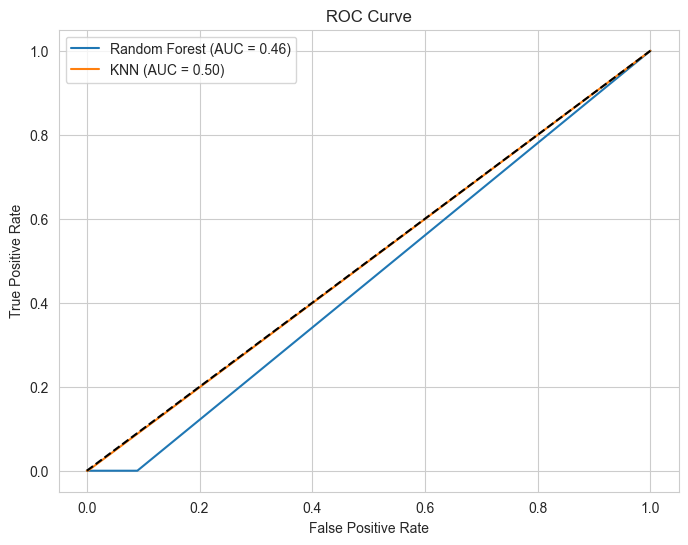

In [27]:
# Fungsi untuk menampilkan perbandingan performa model
def compare_models(models, model_names, X_test, y_test):
    print("\nPerbandingan Performa Model:")
    print("-" * 40)
    for model, name in zip(models, model_names):
        pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, pred)
        f1 = f1_score(y_test, pred, average='weighted')
        print(f"{name}:")
        print(f"  Akurasi: {accuracy:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        print("-" * 40)

# Daftar model dan nama
models = [rf_model, best_rf, knn_model, best_knn]
model_names = ["Random Forest (Sebelum Tuning)", "Random Forest (Setelah Tuning)", 
               "KNN (Sebelum Tuning)", "KNN (Setelah Tuning)"]

# Panggil fungsi perbandingan
compare_models(models, model_names, X_test, y_test)

# Analisis Kelemahan Model
print("\nAnalisis Kelemahan Model:")
print("-" * 40)

# Analisis untuk Random Forest
best_rf_pred = best_rf.predict(X_test)
print("Random Forest:")
rf_cm = confusion_matrix(y_test, best_rf_pred)
print("  - Confusion Matrix:\n", rf_cm)
print("  - Precision dan Recall per kelas:\n", classification_report(y_test, best_rf_pred))
print("  - Kemungkinan overfitting jika akurasi training jauh lebih tinggi dari testing.")
print("-" * 40)

# Analisis untuk KNN
best_knn_pred = best_knn.predict(X_test)
print("KNN:")
knn_cm = confusion_matrix(y_test, best_knn_pred)
print("  - Confusion Matrix:\n", knn_cm)
print("  - Precision dan Recall per kelas:\n", classification_report(y_test, best_knn_pred))
print("  - Sensitif terhadap skala data dan outliers.")
print("-" * 40)

# Rekomendasi untuk Peningkatan
print("\nRekomendasi untuk Peningkatan:")
print("-" * 40)
print("1. Gunakan Random Forest sebagai model utama karena performa yang lebih baik.")
print("2. Kumpulkan lebih banyak data untuk kelas minoritas untuk mengurangi bias.")
print("3. Eksperimen dengan algoritma lain seperti SVM atau Gradient Boosting.")
print("4. Lakukan feature engineering tambahan, misalnya dengan menggabungkan fitur baru.")
print("5. Terapkan teknik oversampling (misalnya SMOTE) untuk menangani ketidakseimbangan kelas.")
print("-" * 40)

# Visualisasi ROC Curve (jika klasifikasi biner)
if len(np.unique(y_test)) == 2:
    plt.figure(figsize=(8, 6))
    for model, name in zip([best_rf, best_knn], ["Random Forest", "KNN"]):
        prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()
else:
    print("ROC Curve tidak ditampilkan karena klasifikasi multiclass.")